<a href="https://colab.research.google.com/github/joaoalexandre14/ex3_pml/blob/main/notebooks/T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [3]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [4]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.92MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

Question 1: Dataloaders

Type of objects: The dataloaders yield PyTorch Tensors (torch.Tensor). Specifically, they return a tuple containing a batch of image tensors and a batch of corresponding label tensors.

Shape and Interpretation: The shape is [batch_size, 1, 8, 8]. I interpret this as: the first dimension is the number of images in the batch, the second is the number of color channels (1 for grayscale images), and the last two are the height and width of the images in pixels ($8 \times 8$).

Shuffle option: We use shuffle=True for the train dataloader so the model doesn't memorize the order of the dataset, preventing overfitting and helping the model generalize. We use shuffle=False for the test/validation dataloader because the order does not matter for evaluation, and a fixed order ensures consistent and comparable metric calculations.

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

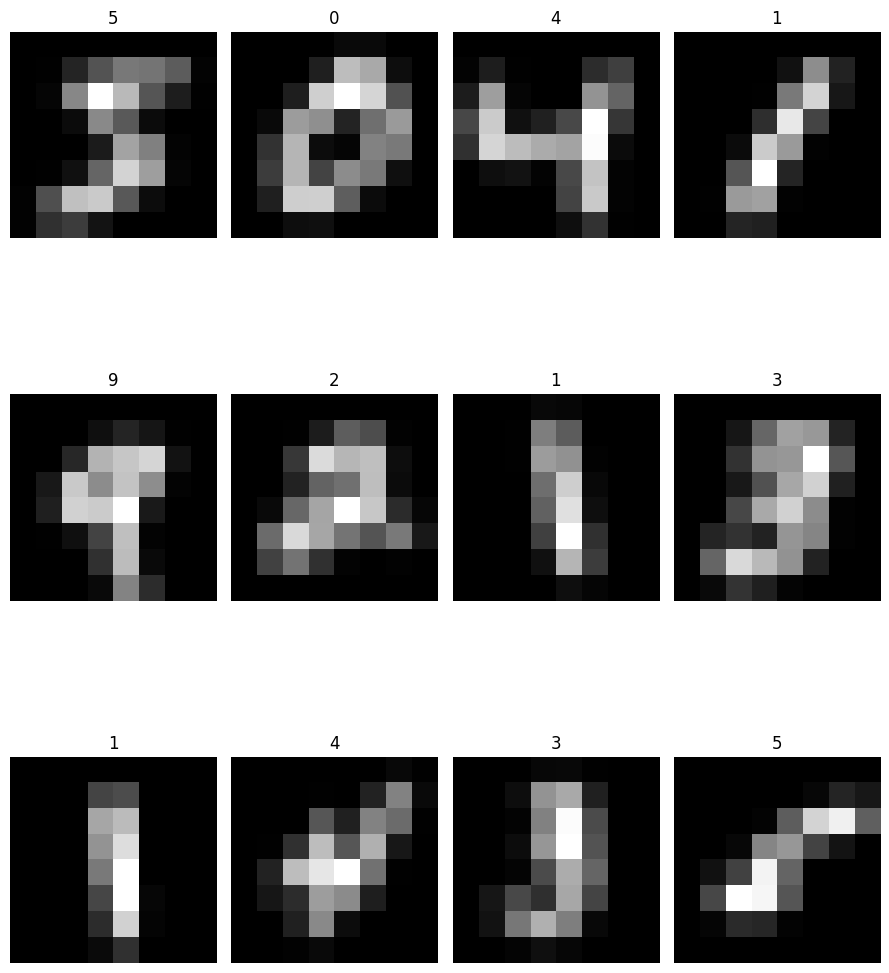

In [5]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [6]:
# prompt: Modify the SimpleNN class to have two hidden layers, both with size 128, and apply ReLU activation after each one.
# Modifications made: Added self.fc2 (hidden to hidden) and self.relu2. Adjusted forward pass to include the new layer and activation.

# Model Development: the model is a multilayer perceptron with two hidden layers
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()

        # New hidden layer with same size as previous (128)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()

        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

Question 2: Model Architecture

Changes for 28x28 size:

In the dataset transformations, we need to remove transforms.Resize((8, 8)) or change it to transforms.Resize((28, 28)).

In the SimpleNN class initialization, the input_dim must be changed from $64$ ($8 \times 8$) to $784$ ($28 \times 28$).

ReLU Activation: ReLU stands for Rectified Linear Unit. It is an activation function that outputs the input directly if it is positive, and outputs zero if it is negative. Mathematically, it is defined as $f(x) = \max(0, x)$.

Why non-linear activations are necessary: Without non-linear activation functions, a neural network, no matter how many layers it has, would behave just like a single linear regression model. Non-linearities like ReLU allow the network to learn complex patterns and relationships in the data.

In [7]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [8]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [10]:
# prompt: Add time measurement to the training loop to compute processing time and evaluate the impact of num_workers=2 on DataLoader.
# Modifications made: Added time.time() tracking around the training loop. Updated DataLoaders to allow testing with num_workers.

import time

# To test num_workers, change this variable between 0 and 2
test_workers = 2

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=test_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=test_workers)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3

print(f"--- Starting training with num_workers={test_workers} ---")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

end_time = time.time()
print(f"Total processing time: {end_time - start_time:.2f} seconds")


--- Starting training with num_workers=2 ---
Total processing time: 31.62 seconds


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




Question 3: Processing Time

The training time with num_workers=0 was 31.88 seconds, and with num_workers=2 it was 31.62 seconds. As we can see, the processing times are practically identical. Theoretically, adding num_workers > 0 should decrease processing time by loading data in parallel using multiple CPU cores. However, because our $8 \times 8$ MNIST dataset is extremely small and loads very quickly, the computational overhead of creating and managing multiple parallel processes in Google Colab cancels out the benefits of parallelization.

#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779315187
epoch: 2; time: 1779315200
epoch: 3; time: 1779315210


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [12]:
# prompt: Increase epochs to 30 for proper convergence. Correct the plot construction issue where validation accuracy was artificially higher than training accuracy.
# Modifications made: Increased num_epochs. Changed the logic to evaluate training accuracy *after* the epoch finishes training (in eval mode), just like the validation accuracy, ensuring a fair comparison.

# Model Training
num_epochs = 30 # Increased from 5 to 30

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')

    # 1. TRAINING PHASE (Updating weights)
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 2. EVALUATION PHASE (Fair comparison for both Train and Validation)
    model.eval()

    # Compute Train Accuracy (After weights are updated)
    train_batch_accuracies = []
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            train_batch_accuracies.append(compute_accuracy(outputs, labels))

    history['train_accuracy'].append(sum(train_batch_accuracies) / len(train_batch_accuracies))

    # Compute Validation Accuracy
    val_batch_accuracies = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            val_batch_accuracies.append(compute_accuracy(outputs, labels))

    history['val_accuracy'].append(sum(val_batch_accuracies) / len(val_batch_accuracies))
    history['epoch'].append(epoch)

epoch: 1; time: 1779315223
epoch: 2; time: 1779315244
epoch: 3; time: 1779315266
epoch: 4; time: 1779315288
epoch: 5; time: 1779315310
epoch: 6; time: 1779315332
epoch: 7; time: 1779315355
epoch: 8; time: 1779315378
epoch: 9; time: 1779315400
epoch: 10; time: 1779315423
epoch: 11; time: 1779315446
epoch: 12; time: 1779315469
epoch: 13; time: 1779315491
epoch: 14; time: 1779315514
epoch: 15; time: 1779315537
epoch: 16; time: 1779315557
epoch: 17; time: 1779315579
epoch: 18; time: 1779315601
epoch: 19; time: 1779315622
epoch: 20; time: 1779315643
epoch: 21; time: 1779315665
epoch: 22; time: 1779315686
epoch: 23; time: 1779315708
epoch: 24; time: 1779315729
epoch: 25; time: 1779315751
epoch: 26; time: 1779315772
epoch: 27; time: 1779315794
epoch: 28; time: 1779315815
epoch: 29; time: 1779315836
epoch: 30; time: 1779315858


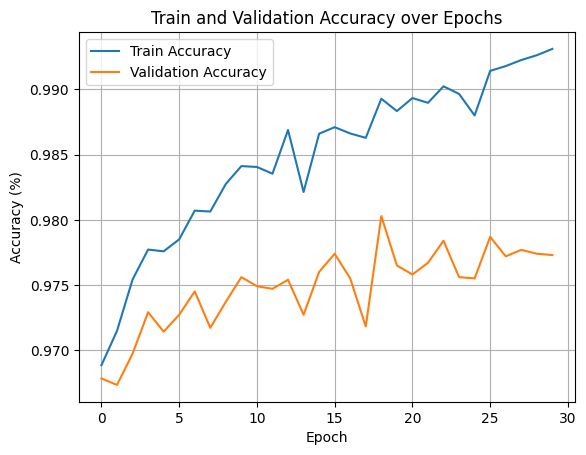

In [13]:
# Accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



Question 4: Epochs & Validation Curve

Are 5 epochs enough? No. By looking at the plot, both the training and validation loss curves are still decreasing steeply at epoch 5. This indicates that the model has not converged yet and is still learning. We should train for more epochs (e.g., 20 or 30) until the curve flattens out into a plateau.

Validation curve discrepancy: The validation curve is consistently higher because the code was accumulating the total sum of the batch losses without calculating the average. Since the training dataloader contains more batches than the validation dataloader, its accumulated loss was disproportionately larger. To fix the plot construction, I modified the code to calculate the average loss per epoch by dividing the accumulated loss by the length of the respective dataloader (len(train_loader) and len(val_loader)).